<a href="https://colab.research.google.com/github/viti990/Physics-Informed-Neural-Networks/blob/main/SolvingNewtonLawOfCoolingPINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Constants
Tamb = 27
T0 = 250
k = 0.45

In [3]:
model = nn.Sequential(
       nn.Linear(in_features=1,out_features=50),
       nn.Tanh(),
       nn.Linear(in_features=50, out_features=50),
       nn.Tanh(),
       nn.Linear(in_features=50,out_features=50),
       nn.Tanh(),
       nn.Linear(in_features=50, out_features=1)
      )
model

Sequential(
  (0): Linear(in_features=1, out_features=50, bias=True)
  (1): Tanh()
  (2): Linear(in_features=50, out_features=50, bias=True)
  (3): Tanh()
  (4): Linear(in_features=50, out_features=50, bias=True)
  (5): Tanh()
  (6): Linear(in_features=50, out_features=1, bias=True)
)

In [4]:
def PDE(t, model):
  t = t.clone().detach().requires_grad_(True)
  y = model(t)
  dydt = torch.autograd.grad(y, t, torch.ones_like(y), create_graph=True)[0]
  return dydt - k*(Tamb-y)

In [5]:
def loss_fn(t, model, t_ic, T_ic):

  loss_pde = torch.mean(torch.square(PDE(t, model)))
  loss_ic = torch.mean(torch.square(T_ic - model(t_ic)))
  return loss_pde + loss_ic

In [6]:
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer,
    gamma=0.95
)

In [7]:
t_train = torch.tensor(np.linspace(0, 10, 100).reshape(-1,1), dtype=torch.float32)
t_ic = torch.tensor(np.array([0.0], dtype=np.float32).reshape(-1,1))
T_ic = torch.tensor(np.array([T0], dtype=np.float32).reshape(-1,1))

In [8]:
torch.manual_seed(42)
epochs = 15000

for epoch in range(epochs):
  model.train()
  y_pred = model(t_train)
  loss = loss_fn(t_train, model, t_ic, T_ic)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if epoch % 500 == 0:
    scheduler.step()
    print(f"Epoch: {epoch} | Train loss: {loss}")

Epoch: 0 | Train loss: 62738.796875
Epoch: 500 | Train loss: 4589.5078125
Epoch: 1000 | Train loss: 171.8519287109375
Epoch: 1500 | Train loss: 109.18112182617188
Epoch: 2000 | Train loss: 104.31687927246094
Epoch: 2500 | Train loss: 1.7622172832489014
Epoch: 3000 | Train loss: 0.953289806842804
Epoch: 3500 | Train loss: 0.5172706246376038
Epoch: 4000 | Train loss: 0.6015819907188416
Epoch: 4500 | Train loss: 0.015574194490909576
Epoch: 5000 | Train loss: 0.13250663876533508
Epoch: 5500 | Train loss: 0.002069454174488783
Epoch: 6000 | Train loss: 0.0017714682035148144
Epoch: 6500 | Train loss: 0.5023964643478394
Epoch: 7000 | Train loss: 0.00048424923443235457
Epoch: 7500 | Train loss: 0.0004348521470092237
Epoch: 8000 | Train loss: 0.08926031738519669
Epoch: 8500 | Train loss: 0.00032577887759543955
Epoch: 9000 | Train loss: 0.16340868175029755
Epoch: 9500 | Train loss: 0.018092432990670204
Epoch: 10000 | Train loss: 0.0013830553507432342
Epoch: 10500 | Train loss: 0.00022520148195326

In [9]:
t_test = torch.tensor(np.linspace(0,10,1000).reshape(-1,1), dtype=torch.float32)
model.eval()
with torch.inference_mode():
  T_pred = model(t_test)

In [10]:
#Analytical solution
T_true = Tamb + (T0 - Tamb)* np.exp(-k*t_test)

/tmp/ipykernel_22517/2389683524.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  T_true = Tamb + (T0 - Tamb)* np.exp(-k*t_test)


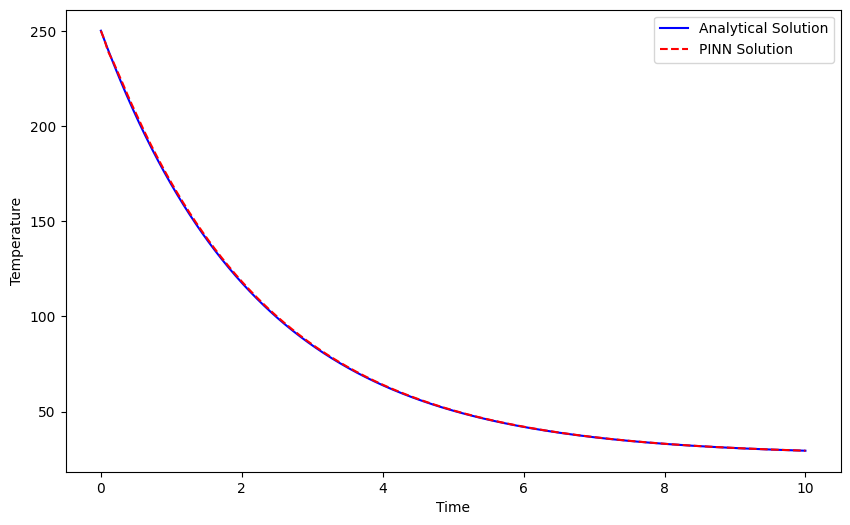

In [11]:
#Plotting
plt.figure(figsize=(10,6))
plt.plot(t_test, T_true, 'b-', label='Analytical Solution')
plt.plot(t_test, T_pred, 'r--', label='PINN Solution')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()